In [4]:
using Pkg
Pkg.activate(".")
Pkg.add("RCall")
Pkg.add("StatsPlots")
Pkg.add("BSON")
Pkg.add("LaTeXStrings")
Pkg.add("PrettyTables")
Pkg.add("GLM")
Pkg.add("DataFrames")

  Activating new project at `c:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication`
   Resolving package versions...
   Installed StatsModels ─ v0.7.6
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Project.toml`
  [6f49c342] + RCall v0.14.9
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Manifest.toml`
  [66dad0bd] + AliasTables v1.1.3
  [324d7699] + CategoricalArrays v1.0.1
  [34da2185] + Compat v4.18.0
  [8f4d0f93] + Conda v1.10.2
  [a8cc5b0e] + Crayons v4.1.1
  [9a962f9c] + DataAPI v1.16.0
  [a93c6f00] + DataFrames v1.7.0
⌅ [864edb3b] + DataStructures v0.18.22
  [e2d170a0] + DataValueInterfaces v1.0.0
  [ffbed154] + DocStringExtensions v0.9.5
  [34004b35] + HypergeometricFunctions v0.3.28
  [842dd82b] + InlineStrings v1.4.4
  [41ab1584] + InvertedIndices v1.3.1
  [92d709cd] + IrrationalConstants v0.2.

In [5]:
Pkg.add("Plots")
Pkg.add("CSV")

   Resolving package versions...
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Project.toml`
  [91a5bcdd] + Plots v1.40.19
  No Changes to `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Manifest.toml`
   Resolving package versions...
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Project.toml`
  [336ed68f] + CSV v0.10.15
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Manifest.toml`
  [336ed68f] + CSV v0.10.15
  [48062228] + FilePathsBase v0.9.24
  [ea10d353] + WeakRefStrings v1.4.2
  [76eceee3] + WorkerUtilities v1.6.1


In [6]:
Pkg.develop(path = "../src/TvPersistence")

   Resolving package versions...
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Project.toml`
  [06521380] + TvPersistence v0.1.0 `..\src\TvPersistence`
    Updating `C:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication\Manifest.toml`
  [8d5ece8b] + GLMNet v0.7.4
  [06521380] + TvPersistence v0.1.0 `..\src\TvPersistence`
⌅ [78c6b45d] + glmnet_jll v2.0.13+0
        Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated -m`


In [ ]:
using Pkg
Pkg.activate(".")
using Plots, CSV, DataFrames, GLM, Statistics
using StatsPlots
using BSON
using LaTeXStrings
using PrettyTables
using RCall
R"library(tvReg)"
R"library(forecast)"

#include("tvPersistence_functions_Restat_Rev5.jl");

RObject{StrSxp}
 [1] "forecast"  "tvReg"     "Matrix"    "stats"     "graphics"  "grDevices"
 [7] "utils"     "datasets"  "methods"   "base"     


In [14]:
# Function to compute cumulative MSE
function c_mse(errors::Vector{Float64})

    cumulative_mse_values = Vector{Float64}(undef, length(errors))
    cumulative_error = 0
    
    for i in 1:length(errors)
        error = errors[i]
        cumulative_error += error^2
        cumulative_mse_values[i] = cumulative_error / (i)  # Cumulative MSE
    end
    
    return cumulative_mse_values
end

function c_se(errors::Vector{Float64})

    cumulative_mse_values = Vector{Float64}(undef, length(errors))
    cumulative_error = 0
    
    for i in 1:length(errors)
        error = errors[i]
        cumulative_error += error^2
        cumulative_mse_values[i] = cumulative_error / 1  # Cumulative MSE
    end
    
    return cumulative_mse_values
end



function c_mae(errors::Vector{Float64})

    cumulative_mse_values = Vector{Float64}(undef, length(errors))
    cumulative_error = 0
    
    for i in 1:length(errors)
        error = errors[i]
        cumulative_error += abs(error)
        cumulative_mse_values[i] = cumulative_error / (i)  
    end
    
    return cumulative_mse_values
end

# function bias(err::Vector{Float64})

#     # Calculate the cumulative bias
#     cumulative_bias = cumsum(err)
#     return cumulative_bias
# end

function bias(errors::Vector{Float64})

    cumulative_bias_values = Vector{Float64}(undef, length(errors))
    cumulative_error = 0
    
    for i in 1:length(errors)
        error = errors[i]
        cumulative_error += error
        cumulative_bias_values[i] = cumulative_error / (i)  # Cumulative MSE
    end
    
    return cumulative_bias_values
end

function SED_coeff(s1,s2,band)
    data=s1.^2 .- s2.^2;
    R"time <- 1:length($data)
    tv_model <- tvLM($data ~ time,bw=$band)$coefficients"
    return convert(Array{Float64},R"tv_model");
end

function SED_smooth(s1,s2,band)
    data=s1.^2 .- s2.^2;
    R"time <- 1:length($data)
    tv_model <- tvLM($data ~ time,bw=$band)
    smoothed_values <- fitted(tv_model)"
    return convert(Array{Float64},R"smoothed_values");
end

# Function to calculate directional accuracy
function directional_accuracy(actual::Vector{Float64}, forecast::Vector{Float64})
    if length(actual) != length(forecast)
        throw(ArgumentError("The lengths of actual and forecast vectors must be the same."))
    end

    count_correct = 0
    total = 0

    for i in 2:length(actual)  # Start from the second element to compare with the previous one
        actual_direction = sign(actual[i] - actual[i-1])  # Determine the direction of actual
        forecast_direction = sign(forecast[i] - forecast[i-1])  # Determine the direction of forecast
        
        if actual_direction != 0  # Exclude cases where the actual direction is zero
            total += 1
            if actual_direction == forecast_direction
                count_correct += 1
            end
        end
    end

    if total == 0
        return 0.0  # Avoid division by zero if all directions were zero
    end

    return count_correct / total  # Return directional accuracy as a proportion
end


function dir_acc(forecasts, num)
    accuracy=[]
    for i in 2:num
        push!(accuracy, directional_accuracy(forecasts[:, 1], forecasts[:, i]))
    end
    return accuracy
end

dir_acc (generic function with 1 method)

In [18]:
function ratio(error,t1,t2,loss,num_los)
    
    benchmark=1
    num_loss=num_los
    
    if loss == "RMSE"
    
        rat=Float64.(hcat([[sqrt(mean(error[j][t1:t2,k].^2))/sqrt(mean(error[j][t1:t2,benchmark].^2)) for j=1:size(error)[1]] for k=1:num_loss]...)')
        rat=rat[Not(benchmark),:];
    elseif loss == "MAE"
        rat=Float64.(hcat([[mean(abs.(error[j][t1:t2,k]))/mean(abs.(error[j][t1:t2,benchmark])) for j=1:size(error)[1]] for k=1:num_loss]...)')
        rat=rat[Not(benchmark),:];
    elseif loss == "MMEO"
        rat=Float64.(hcat([[(1/length(error[1][t1:t2,k])*(sum(abs.((error[j][t1:t2,k].<0).*error[j][t1:t2,k]))+sum(sqrt.(abs.((error[j][t1:t2,k].>0).*error[j][t1:t2,k])))))/
                        (1/length(error[1][t1:t2,benchmark])*(sum(abs.((error[j][t1:t2,benchmark].<0).*error[j][t1:t2,benchmark]))+sum(sqrt.(abs.((error[j][t1:t2,benchmark].>0).*error[j][t1:t2,benchmark])))))  
                        for j=1:size(error)[1]] for k=1:num_loss]...)')
        rat=rat[Not(benchmark),:];
    elseif loss == "MMEU"
        rat=Float64.(hcat([[(1/length(error[1][t1:t2,k])*(sum(abs.((error[j][t1:t2,k].>0).*error[j][t1:t2,k]))+sum(sqrt.(abs.((error[j][t1:t2,k].<0).*error[j][t1:t2,k])))))/
                        (1/length(error[1][t1:t2,benchmark])*(sum(abs.((error[j][t1:t2,benchmark].>0).*error[j][t1:t2,benchmark]))+sum(sqrt.(abs.((error[j][t1:t2,benchmark].<0).*error[j][t1:t2,benchmark])))))  
                        for j=1:size(error)[1]] for k=1:num_loss]...)')
        rat=rat[Not(benchmark),:];
    elseif loss == "MMEUpercentage"
        rat=Float64.(hcat([[sum(error[j][t1:t2,k].<0)/length(error[1][t1:t2,k]) for j=1:size(error)[1]] for k=1:num_loss]...)')
    end
    
        return rat
end

ratio (generic function with 2 methods)

In [19]:
tt=610     

test1 = BSON.load("results_Inflation_$tt-1.bson")
test2 = BSON.load("results_Inflation_$tt-2.bson")
test6 = BSON.load("results_Inflation_$tt-6.bson")
test12 = BSON.load("results_Inflation_$tt-12.bson")

# res=[Error_RW Error_AR2 Error_AR7 Error_EWD Error_AR2tv Error_EWDtv]

res1=test1["errors"];
res2=test2["errors"];
res6=test6["errors"];
res12=test12["errors"];

# forecasts=[RV_h horizon_forecast_RW horizon_forecast_AR2 horizon_forecast_AR7 horizon_forecast_EWD horizon_forecast_AR2tv horizon_forecast_EWDtv]

forecasts1=test1["forecasts"];
forecasts2=test2["forecasts"];
forecasts6=test6["forecasts"];
forecasts12=test12["forecasts"];

## MSE and MAE:

In [20]:
## 1:Error_HAR 2:Error_EWD 3:ErrorAR3tv 4:ErrorHARtv 5:ErrorEWDtv

loss="RMSE"    # RMSE, MAE, MMEO, MMEU, MMEUpercentage
# loss="MAE"    # RMSE, MAE, MMEO, MMEU, MMEUpercentage

t1=1
t2=size(res1[1])[1] # fullsample

resultsexp1=ratio(res1,t1,t2,loss,6)
pos=findall(x->x==1,isnan.(resultsexp1))
resultsexp1=resultsexp1[:,Not([pos[k][2] for k=1:length(pos)])]

resultsexp2=ratio(res2,t1,t2-1,loss,6)
pos=findall(x->x==1,isnan.(resultsexp2))
resultsexp2=resultsexp2[:,Not([pos[k][2] for k=1:length(pos)])]

resultsexp6=ratio(res6,t1,t2-5,loss,6)
pos=findall(x->x==1,isnan.(resultsexp6))
resultsexp6=resultsexp6[:,Not([pos[k][2] for k=1:length(pos)])]

resultsexp12=ratio(res12,t1,t2-11,loss,6)
pos=findall(x->x==1,isnan.(resultsexp12))
resultsexp12=resultsexp12[:,Not([pos[k][2] for k=1:length(pos)])];

outtab=([ median(resultsexp1,dims=2) median(resultsexp2,dims=2) median(resultsexp6,dims=2) median(resultsexp12,dims=2)])
pretty_table([["AR(2)";"AR(7)";"EWD(2)";"TV-AR(2)";"EWDtv(2-3)"] outtab];header=["RMSE";"h 1"; "h 2" ;"h 6" ;"h 12"],tf = tf_compact,formatters = ft_round(4,[i for i in 1:6]))

In [21]:
## 1:Error_HAR 2:Error_EWD 3:ErrorAR3tv 4:ErrorHARtv 5:ErrorEWDtv

# loss="RMSE"    # RMSE, MAE, MMEO, MMEU, MMEUpercentage
loss="MAE"    # RMSE, MAE, MMEO, MMEU, MMEUpercentage

t1=1
t2=size(res1[1])[1] # fullsample

resultsexp1=ratio(res1,t1,t2,loss,6)
pos=findall(x->x==1,isnan.(resultsexp1))
resultsexp1=resultsexp1[:,Not([pos[k][2] for k=1:length(pos)])]

resultsexp2=ratio(res2,t1,t2-1,loss,6)
pos=findall(x->x==1,isnan.(resultsexp2))
resultsexp2=resultsexp2[:,Not([pos[k][2] for k=1:length(pos)])]

resultsexp6=ratio(res6,t1,t2-5,loss,6)
pos=findall(x->x==1,isnan.(resultsexp6))
resultsexp6=resultsexp6[:,Not([pos[k][2] for k=1:length(pos)])]

resultsexp12=ratio(res12,t1,t2-11,loss,6)
pos=findall(x->x==1,isnan.(resultsexp12))
resultsexp12=resultsexp12[:,Not([pos[k][2] for k=1:length(pos)])];

outtab=([ median(resultsexp1,dims=2) median(resultsexp2,dims=2) median(resultsexp6,dims=2) median(resultsexp12,dims=2)])
pretty_table([["AR(2)";"AR(7)";"EWD(2)";"TV-AR(2)";"EWDtv(2-3)"] outtab];header=["MAE";"h 1"; "h 2" ;"h 6" ;"h 12"],tf = tf_compact,formatters = ft_round(4,[i for i in 1:6]))

 ------------ -------- -------- -------- --------
        RMSE      h 1      h 2      h 6     h 12 
 ------------ -------- -------- -------- --------
       AR(2)   0.8933   0.8306    0.757   0.8756
       AR(7)   0.8429   0.7489   0.6267   0.6753
      EWD(2)    0.911   0.8378   0.7151   0.7833
    TV-AR(2)   0.9783   0.8561    0.759   0.8222
  EWDtv(2-3)   0.8452   0.8859   0.9733   1.0342
 ------------ -------- -------- -------- --------
 ------------ -------- -------- -------- --------
         MAE      h 1      h 2      h 6     h 12 
 ------------ -------- -------- -------- --------
       AR(2)   0.9316   0.8897   0.8726   1.0953
       AR(7)   0.8758   0.7992   0.6678   0.7409
      EWD(2)   0.9408   0.8847   0.7446    0.752
    TV-AR(2)   1.0387   0.9587   0.8112   0.8206
  EWDtv(2-3)    0.883   0.9422   1.0178   1.0784
 ------------ -------- -------- -------- --------


In [22]:
function gaussian_kernel(x::Float64, x_query::Float64, sigma::Float64)
    dist_sq = (x - x_query)^2
    return exp(-dist_sq / (2 * sigma^2))
end

# Local coefficient of determination (local R²)
function local_mse(error_bench::Vector{Float64}, error_pred::Vector{Float64}, x_query::Float64, sigma::Float64)
    # Ensure the vectors are of the same length
    n = length(error_pred)
    x_coords = collect(1.0:n)
    
    # Compute weights using the Gaussian kernel
    weights = [gaussian_kernel(x_coords[i], x_query, sigma) for i in 1:n]
    
    # Normalize weights
    weights /= sum(weights)
    
    # Compute weighted residual sum of squares (RSS) and total sum of squares (TSS)
    rss = sum(weights .* (error_pred).^2)  # Residual sum of squares
    tss = sum(weights .* (error_bench).^2)  # Total sum of squares
    
    # Compute local MSE
    localmse = rss / tss
    return localmse
end

function OOS_pockets(err_har,err_tvhar,err_tvewd,bandw,bw_sed)

    locR2_tvhar=[local_mse(err_har, err_tvhar, j, bandw) for j=1.0:length(err_tvhar)]
    pockets_tvhar=SED_smooth(err_har,err_tvhar,bw_sed).>0.0

    locR2_tvewd=[local_mse(err_har, err_tvewd, j, bandw) for j=1.0:length(err_tvewd)]
    pockets_tvewd=SED_smooth(err_har,err_tvewd,bw_sed).>0.0
    
    return [sum(locR2_tvhar.*pockets_tvhar)./sum(pockets_tvhar) sum(locR2_tvewd.*pockets_tvewd)./sum(pockets_tvewd)]
end

OOS_pockets (generic function with 1 method)

# Gains using only pockets and pockets figures for inflation

In [23]:
### Udelat bench AR2 (pak taky AR7) 
Potom taky proti sobe.

UndefVarError: UndefVarError: `Potom` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

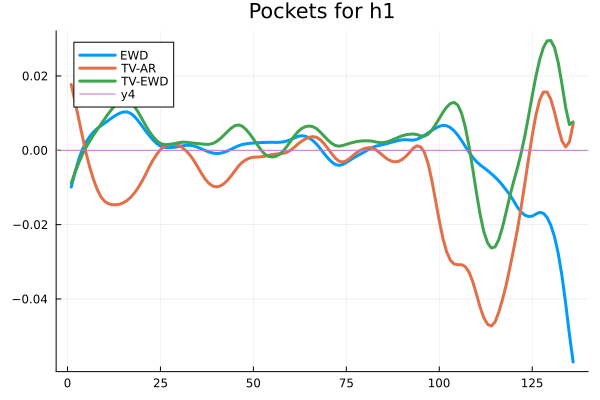

In [24]:
bw=0.07
plot([SED_smooth(res1[][:,2],res1[][:,4],bw) SED_smooth(res1[][:,2],res1[][:,5],bw) SED_smooth(res1[][:,2],res1[][:,6],bw)], linewidth=3, title = "Pockets for h1", label=["EWD" "TV-AR" "TV-EWD"])
hline!([0])
plot!(legend=:topleft)

In [25]:
OOS_pockets(res1[][:,1],res1[][:,5],res1[][:,6],5.0,0.03)

1×2 Matrix{Float64}:
 0.868149  0.706219

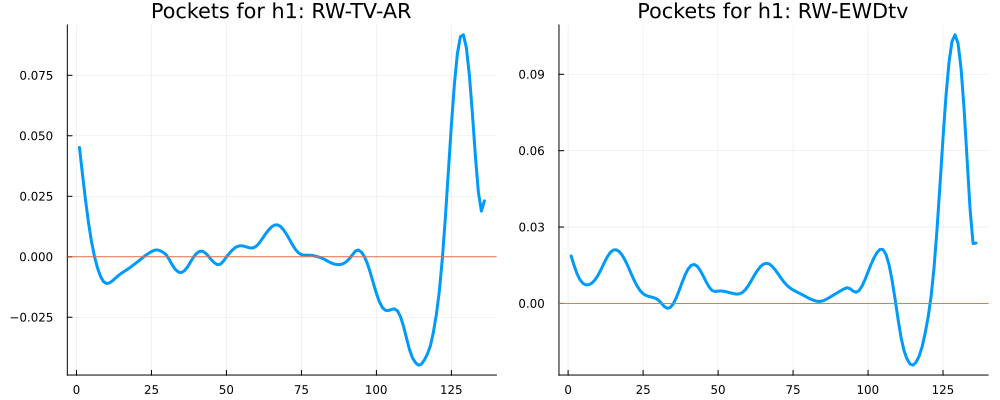

In [26]:
bw=0.07
a=plot(SED_smooth(res1[][:,1],res1[][:,5],bw), linewidth=3, title = "Pockets for h1: RW-TV-AR")
b=plot(SED_smooth(res1[][:,1],res1[][:,6],bw), linewidth=3, title = "Pockets for h1: RW-EWDtv")
plot(a,b, layout = (1,2), legend = false, size = (1000, 400))
hline!([0 0])

In [27]:
# OOS_pockets(res2[][:,1],res2[][:,5],res2[][:,6],5.0,0.03)
OOS_pockets(res2[][:,1],res2[][:,5],res2[][:,6],10.0,0.03)

1×2 Matrix{Float64}:
 0.732961  0.736424

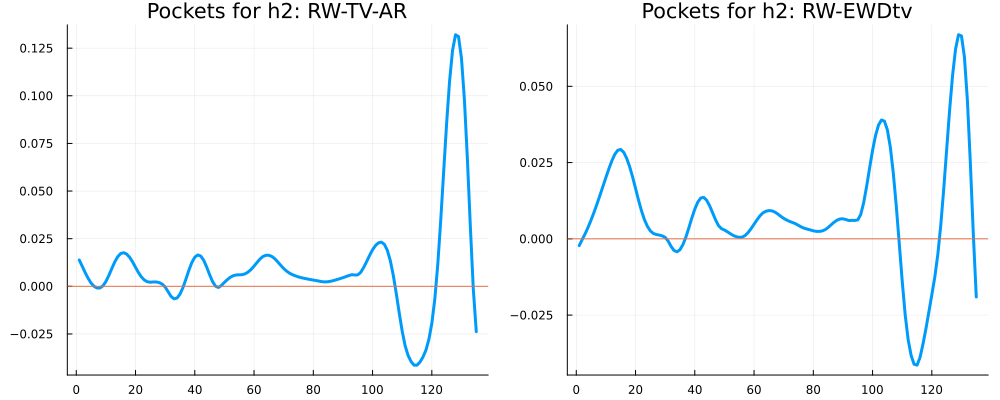

In [28]:
bw=0.07
a=plot(SED_smooth(res2[][:,1],res2[][:,5],bw), linewidth=3, title = "Pockets for h2: RW-TV-AR")
b=plot(SED_smooth(res2[][:,1],res2[][:,6],bw), linewidth=3, title = "Pockets for h2: RW-EWDtv")
plot(a,b, layout = (1,2), legend = false, size = (1000, 400))
hline!([0 0])

In [29]:
# OOS_pockets(res6[][:,1],res6[][:,5],res6[][:,6],5.0,0.03)
OOS_pockets(res6[][:,1],res6[][:,5],res6[][:,6],25.0,0.03)

1×2 Matrix{Float64}:
 0.560606  0.908126

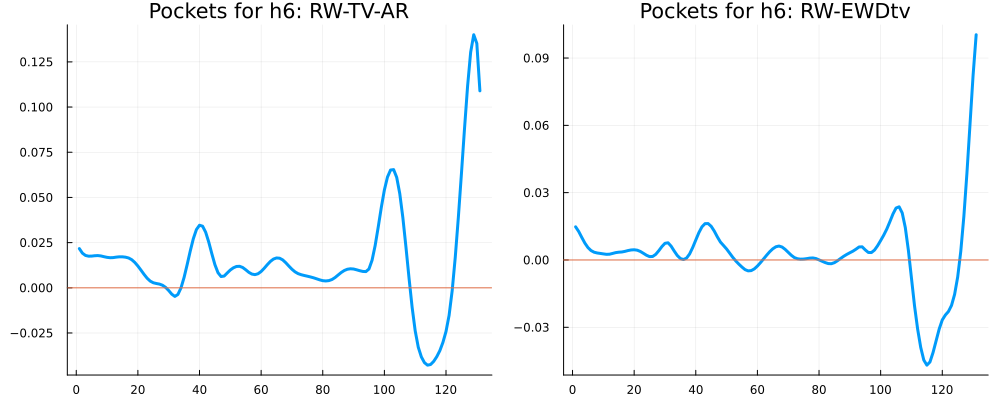

In [30]:
bw=0.07
a=plot(SED_smooth(res6[][:,1],res6[][:,5],bw), linewidth=3, title = "Pockets for h6: RW-TV-AR")
b=plot(SED_smooth(res6[][:,1],res6[][:,6],bw), linewidth=3, title = "Pockets for h6: RW-EWDtv")
plot(a,b, layout = (1,2), legend = false, size = (1000, 400))
hline!([0 0])

In [31]:
# OOS_pockets(res12[][:,1],res12[][:,5],res12[][:,6],5.0,0.03)
OOS_pockets(res12[][:,1],res12[][:,5],res12[][:,6],50.0,0.07)

1×2 Matrix{Float64}:
 0.608494  1.0197

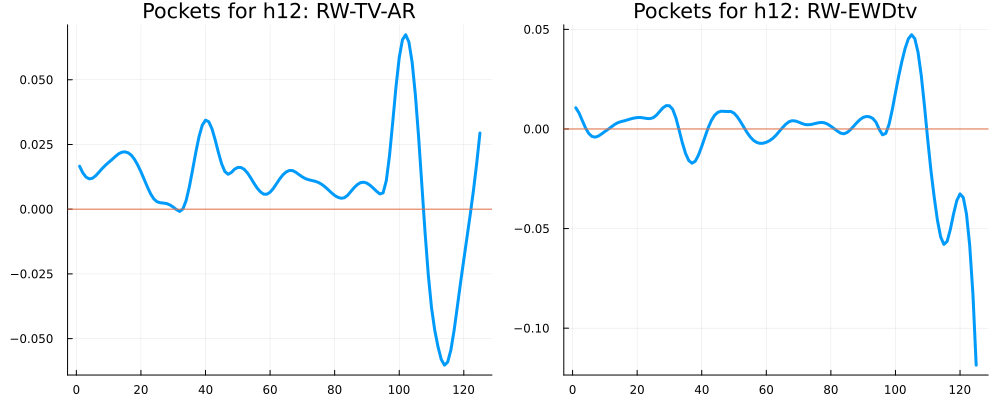

In [32]:
bw=0.07
a=plot(SED_smooth(res12[][:,1],res12[][:,5],bw), linewidth=3, title = "Pockets for h12: RW-TV-AR")
b=plot(SED_smooth(res12[][:,1],res12[][:,6],bw), linewidth=3, title = "Pockets for h12: RW-EWDtv")
plot(a,b, layout = (1,2), legend = false, size = (1000, 400))
hline!([0 0])

# Difference of cummulative MSE - bench is RW

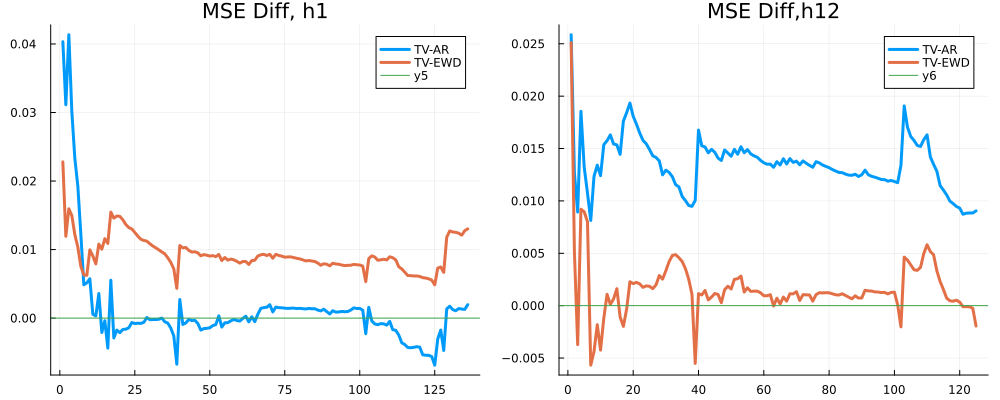

In [33]:
a=plot([c_mse(res1[][:,1])-c_mse(res1[][:,5]) c_mse(res1[][:,1])-c_mse(res1[][:,6])], linewidth=3, title = "MSE Diff, h1", label=["TV-AR" "TV-EWD"])
b=plot([c_mse(res12[][:,1])-c_mse(res12[][:,5]) c_mse(res12[][:,1])-c_mse(res12[][:,6])], linewidth=3, title = "MSE Diff,h12", label=["TV-AR" "TV-EWD"])
plot(a,b, layout = (1,2), size = (1000, 400))
hline!([0 0])

# Cumulative squred error difference - bench is RW

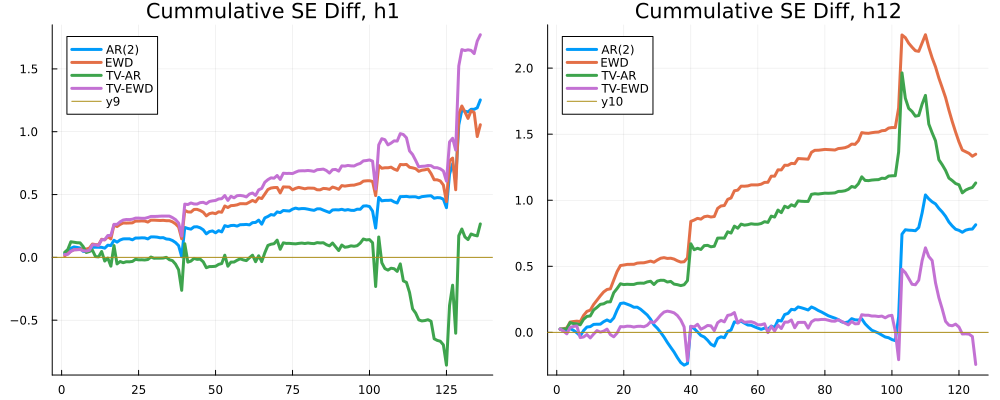

In [34]:
a=plot([cumsum(res1[][:,1].^2 .- res1[][:,2].^2) cumsum(res1[][:,1].^2 .- res1[][:,4].^2) cumsum(res1[][:,1].^2 .- res1[][:,5].^2) cumsum(res1[][:,1].^2 .- res1[][:,6].^2)], linewidth=3, title = "Cummulative SE Diff, h1", label=["AR(2)" "EWD" "TV-AR" "TV-EWD"])
b=plot([cumsum(res12[][:,1].^2 .- res12[][:,2].^2) cumsum(res12[][:,1].^2 .- res12[][:,4].^2) cumsum(res12[][:,1].^2 .- res12[][:,5].^2) cumsum(res12[][:,1].^2 .- res12[][:,6].^2)], linewidth=3, title = "Cummulative SE Diff, h12", label=["AR(2)" "EWD" "TV-AR" "TV-EWD"])
plot(a,b, layout = (1,2), size = (1000, 400))
hline!([0 0])
plot!(legend=:topleft)

# Cumulatime MAE Difference

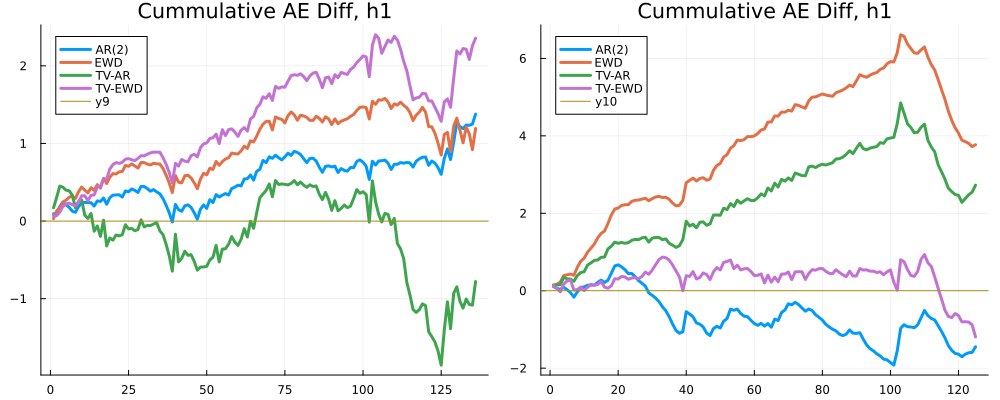

In [35]:
a=plot([cumsum(abs.(res1[][:,1]) .- abs.(res1[][:,2])) cumsum(abs.(res1[][:,1]) .- abs.(res1[][:,4])) cumsum(abs.(res1[][:,1]) .- abs.(res1[][:,5])) cumsum(abs.(res1[][:,1]) .- abs.(res1[][:,6]))], linewidth=3, title = "Cummulative AE Diff, h1", label=["AR(2)" "EWD" "TV-AR" "TV-EWD"])
b=plot([cumsum(abs.(res12[][:,1]) .- abs.(res12[][:,2])) cumsum(abs.(res12[][:,1]) .- abs.(res12[][:,4])) cumsum(abs.(res12[][:,1]) .- abs.(res12[][:,5])) cumsum(abs.(res12[][:,1]) .- abs.(res12[][:,6]))], linewidth=3, title = "Cummulative AE Diff, h1", label=["AR(2)" "EWD" "TV-AR" "TV-EWD"])
plot(a,b, layout = (1,2), size = (1000, 400))
hline!([0 0])
plot!(legend=:topleft)

# Cummulative (mean) Bias

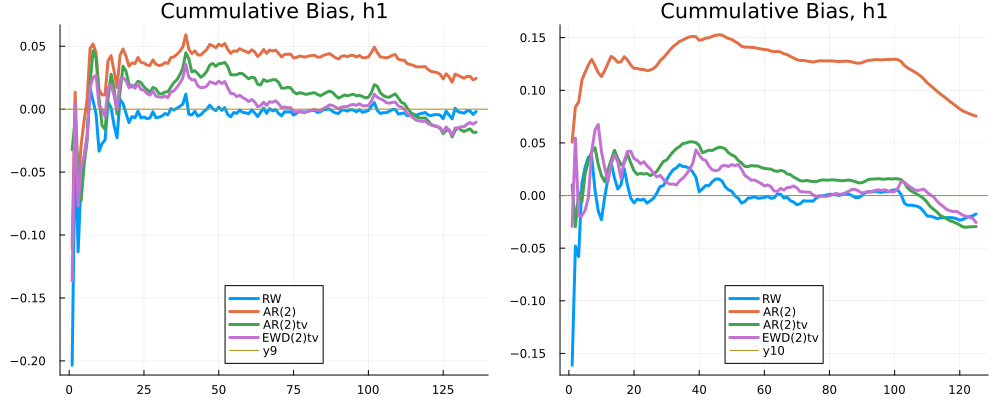

In [36]:
a=plot([bias(res1[][:,1]) bias(res1[][:,2]) bias(res1[][:,5]) bias(res1[][:,6])], linewidth=3, title = "Cummulative Bias, h1", label=["RW" "AR(2)" "AR(2)tv" "EWD(2)tv"])
b=plot([bias(res12[][:,1]) bias(res12[][:,2]) bias(res12[][:,5]) bias(res12[][:,6])], linewidth=3, title = "Cummulative Bias, h1", label=["RW" "AR(2)" "AR(2)tv" "EWD(2)tv"])
plot(a,b, layout = (1,2), size = (1000, 400))
hline!([0 0])
plot!(legend=:bottom)

# Directional Accuracy
 - Check, strange results (it will be interesting for vol.)


In [38]:
outtab=([ dir_acc(forecasts1,7) dir_acc(forecasts2,7) dir_acc(forecasts6,7) dir_acc(forecasts12,7)])
pretty_table([["RW";"AR(2)";"AR(7)";"EWD(2)";"TV-AR(2)";"EWDtv(2-3)"] outtab];header=["d_acc";"h 1"; "h 2" ;"h 6" ;"h 12"],tf = tf_compact,formatters = ft_round(4,[i for i in 1:6]))

 ------------ -------- -------- -------- --------
       d_acc      h 1      h 2      h 6     h 12 
 ------------ -------- -------- -------- --------
          RW   0.4148   0.3433   0.3231   0.3629
       AR(2)   0.3778   0.3209   0.2769   0.3145
       AR(7)   0.4148   0.3358   0.2846   0.3065
      EWD(2)   0.3852   0.3358   0.3077   0.3468
    TV-AR(2)   0.5185   0.4925   0.4769   0.4435
  EWDtv(2-3)    0.437   0.3806   0.3615   0.3065
 ------------ -------- -------- -------- --------
